In [1]:
pip install numpy opencv-python scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/40.2 MB 403.5 kB/s eta 0:01:40
   ---------------------------------------- 0.1/40.2 MB 403.5 kB/s eta 0:01:40
   ---------------------------------------- 0.1/40.2 MB 403.5 kB/s eta 0:01:40
   ---------------------------------------- 0.1/40.2 MB


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd

data = pd.read_csv("UniversalBank.csv")
print(data.columns)

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')


In [6]:
import pandas as pd

data = pd.read_csv("UniversalBank.csv")

data.columns = data.columns.str.strip()

print("Columns in dataset:")
print(data.columns)

# Drop ID & ZIP safely
data = data.drop(columns=['ID', 'ZIPCode'], errors='ignore')

Columns in dataset:
Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')


In [9]:
# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
data = pd.read_csv("UniversalBank.csv")

# Remove extra spaces in column names
data.columns = data.columns.str.strip()

# Drop unnecessary columns safely
data = data.drop(columns=['ID', 'ZIPCode'], errors='ignore')

# Fill missing values if any
data = data.fillna(data.mean())

# Separate Features and Target
X = data.drop('Personal Loan', axis=1)
y = data['Personal Loan']

# Split Data into Training & Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling (Important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build SVM Model
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.976

Confusion Matrix:
 [[892   3]
 [ 21  84]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       895
           1       0.97      0.80      0.88       105

    accuracy                           0.98      1000
   macro avg       0.97      0.90      0.93      1000
weighted avg       0.98      0.98      0.97      1000



In [10]:
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)
print("Linear SVM Accuracy:", model_linear.score(X_test, y_test))

Linear SVM Accuracy: 0.953


In [11]:
model_poly = SVC(kernel='poly', degree=3)
model_poly.fit(X_train, y_train)
print("Polynomial SVM Accuracy:", model_poly.score(X_test, y_test))

Polynomial SVM Accuracy: 0.969


In [12]:
model_sigmoid = SVC(kernel='sigmoid')
model_sigmoid.fit(X_train, y_train)
print("Sigmoid SVM Accuracy:", model_sigmoid.score(X_test, y_test))

Sigmoid SVM Accuracy: 0.888


In [13]:
model_c = SVC(kernel='rbf', C=10)
model_c.fit(X_train, y_train)
print("SVM with C=10 Accuracy:", model_c.score(X_test, y_test))

SVM with C=10 Accuracy: 0.983


In [14]:
model_poly = SVC(kernel='poly', degree=3)
model_poly.fit(X_train, y_train)
print("Polynomial SVM Accuracy:", model_poly.score(X_test, y_test))

Polynomial SVM Accuracy: 0.969


In [15]:
model_c = SVC(kernel='rbf', C=10)
model_c.fit(X_train, y_train)
print("SVM with C=10 Accuracy:", model_c.score(X_test, y_test))

SVM with C=10 Accuracy: 0.983


In [16]:
model_gamma = SVC(kernel='rbf', gamma=0.01)
model_gamma.fit(X_train, y_train)
print("SVM with gamma=0.01 Accuracy:", model_gamma.score(X_test, y_test))

SVM with gamma=0.01 Accuracy: 0.958


In [17]:
from sklearn.model_selection import cross_val_score

model = SVC(kernel='rbf')
scores = cross_val_score(model, X, y, cv=5)
print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.9040000000000001


In [18]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [1, 10],
    'gamma': [0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), params, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [20]:
print("Loan Not Approved:", sum(y == 0))
print("Loan Approved:", sum(y == 1))

Loan Not Approved: 4520
Loan Approved: 480


In [21]:
model_prob = SVC(kernel='rbf', probability=True)
model_prob.fit(X_train, y_train)

print("Probability:", model_prob.predict_proba(X_test[:5]))

Probability: [[9.97615654e-01 2.38434629e-03]
 [5.27578010e-03 9.94724220e-01]
 [9.61677671e-01 3.83223286e-02]
 [9.92697826e-01 7.30217387e-03]
 [9.99955943e-01 4.40567637e-05]]


In [23]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

for k in kernels:
    m = SVC(kernel=k)
    m.fit(X_train, y_train)
    print(k, "Accuracy:", m.score(X_test, y_test))

linear Accuracy: 0.953
rbf Accuracy: 0.976
poly Accuracy: 0.969
sigmoid Accuracy: 0.888


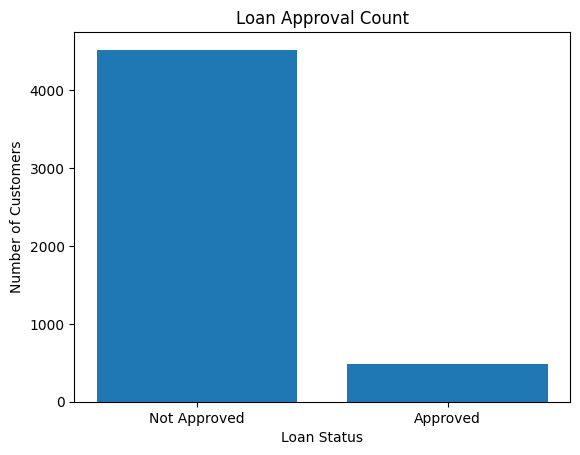

In [24]:
import matplotlib.pyplot as plt

loan_counts = y.value_counts()

plt.bar(['Not Approved', 'Approved'], loan_counts)
plt.title("Loan Approval Count")
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")
plt.show()

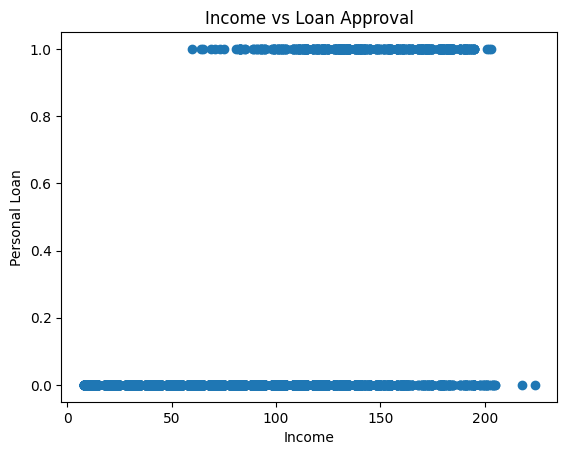

In [25]:
plt.scatter(data['Income'], data['Personal Loan'])
plt.xlabel("Income")
plt.ylabel("Personal Loan")
plt.title("Income vs Loan Approval")
plt.show()

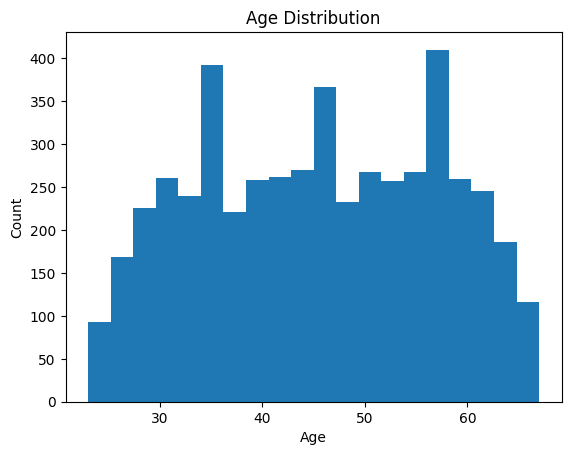

In [26]:
plt.hist(data['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

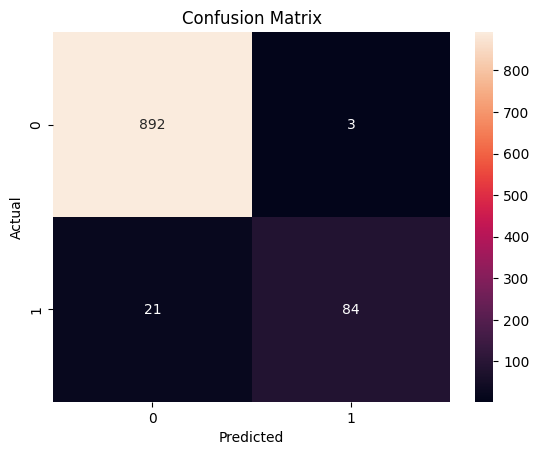

In [27]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

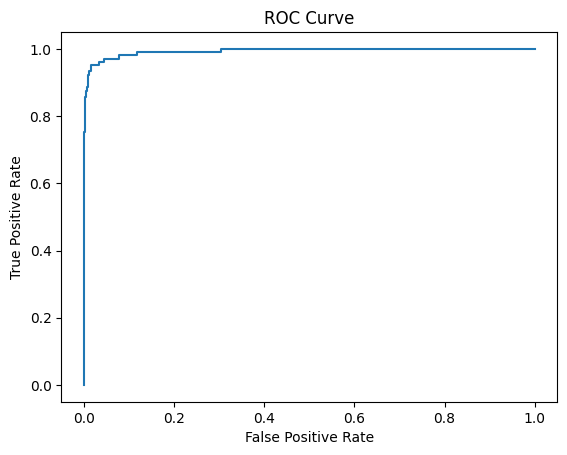

AUC Score: 0.9930087789305667


In [28]:
from sklearn.metrics import roc_curve, auc

model_prob = SVC(kernel='rbf', probability=True)
model_prob.fit(X_train, y_train)

y_prob = model_prob.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc)

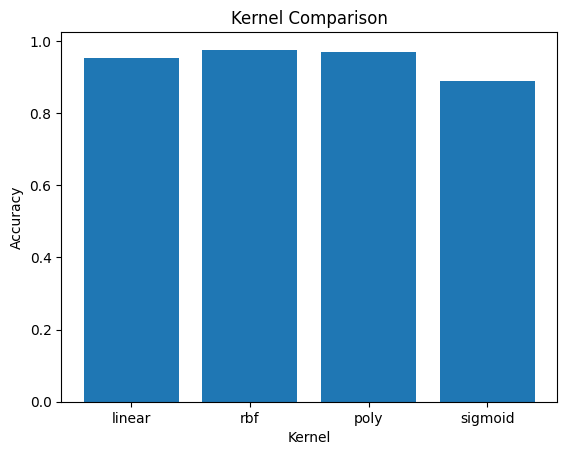

In [29]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
accuracies = []

for k in kernels:
    m = SVC(kernel=k)
    m.fit(X_train, y_train)
    accuracies.append(m.score(X_test, y_test))

plt.bar(kernels, accuracies)
plt.title("Kernel Comparison")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.show()

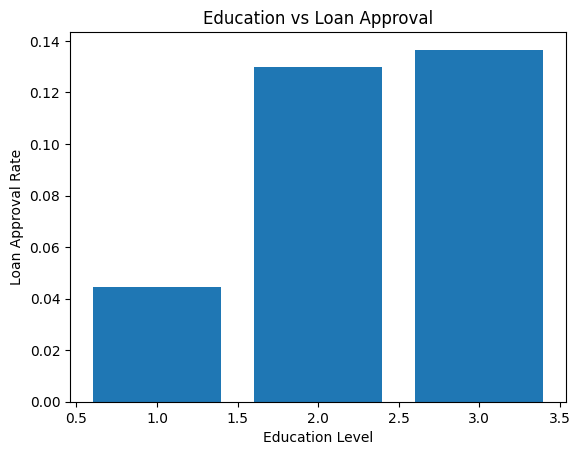

In [30]:
import matplotlib.pyplot as plt

edu_loan = data.groupby('Education')['Personal Loan'].mean()

plt.bar(edu_loan.index, edu_loan.values)
plt.xlabel("Education Level")
plt.ylabel("Loan Approval Rate")
plt.title("Education vs Loan Approval")
plt.show()

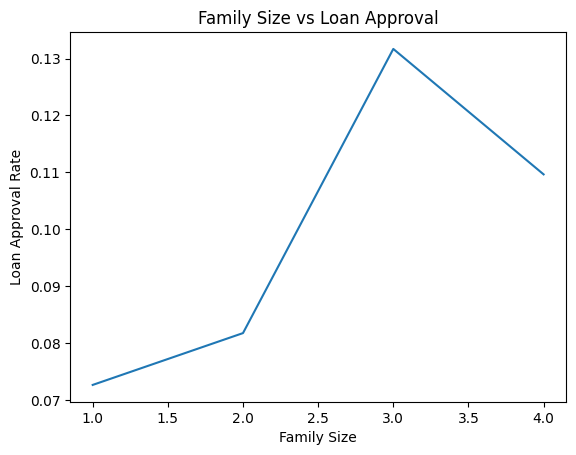

In [31]:
family_loan = data.groupby('Family')['Personal Loan'].mean()

plt.plot(family_loan.index, family_loan.values)
plt.xlabel("Family Size")
plt.ylabel("Loan Approval Rate")
plt.title("Family Size vs Loan Approval")
plt.show()

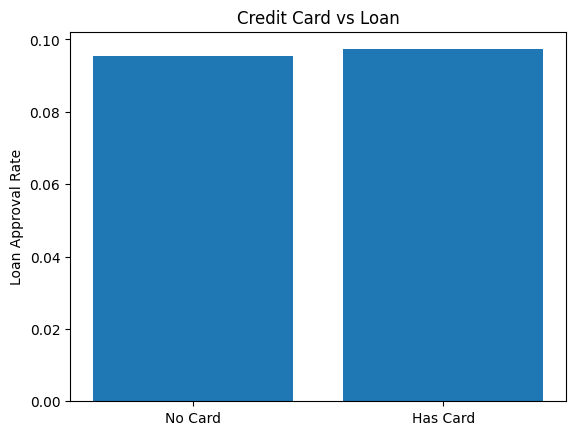

In [32]:
cc_loan = data.groupby('CreditCard')['Personal Loan'].mean()

plt.bar(['No Card','Has Card'], cc_loan)
plt.title("Credit Card vs Loan")
plt.ylabel("Loan Approval Rate")
plt.show()

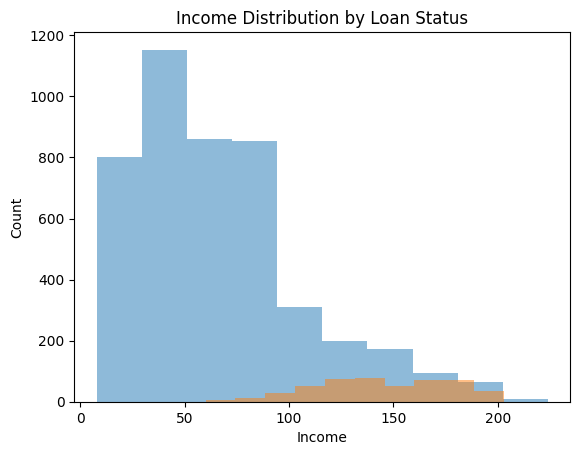

In [33]:
plt.hist(data[data['Personal Loan']==0]['Income'], alpha=0.5)
plt.hist(data[data['Personal Loan']==1]['Income'], alpha=0.5)

plt.xlabel("Income")
plt.ylabel("Count")
plt.title("Income Distribution by Loan Status")
plt.show()

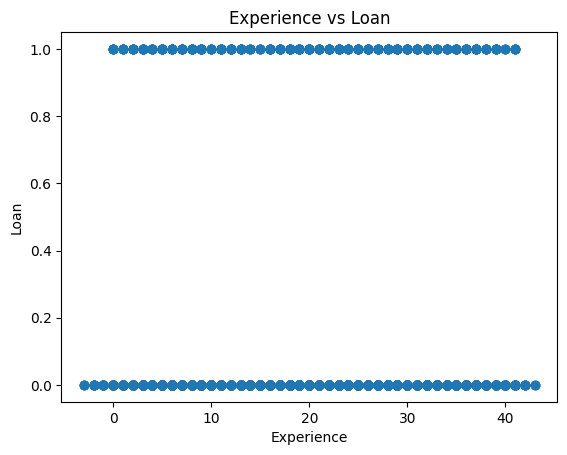

In [34]:
plt.scatter(data['Experience'], data['Personal Loan'])
plt.xlabel("Experience")
plt.ylabel("Loan")
plt.title("Experience vs Loan")
plt.show()

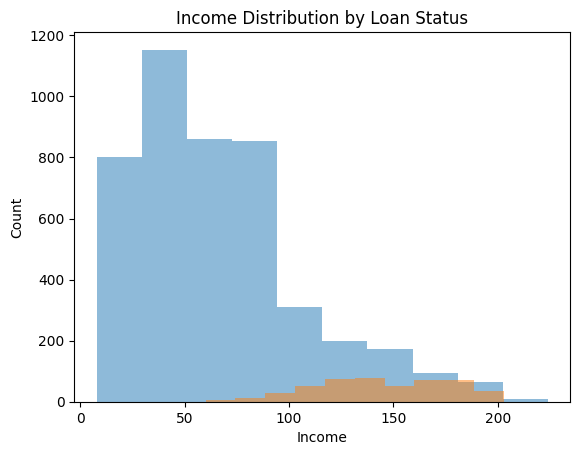

In [35]:
plt.hist(data[data['Personal Loan']==0]['Income'], alpha=0.5)
plt.hist(data[data['Personal Loan']==1]['Income'], alpha=0.5)

plt.xlabel("Income")
plt.ylabel("Count")
plt.title("Income Distribution by Loan Status")
plt.show()

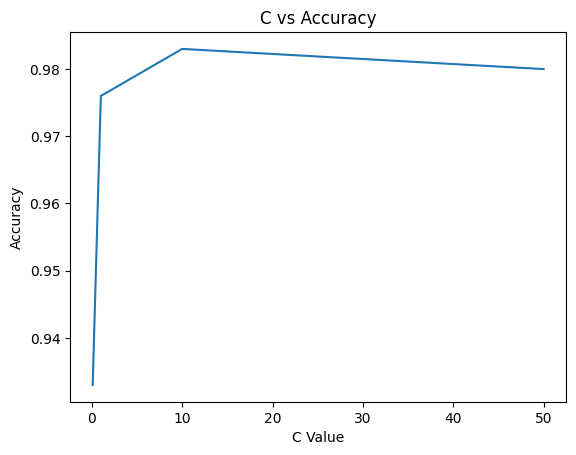

In [36]:
c_values = [0.1, 1, 10, 50]
accuracies = []

for c in c_values:
    m = SVC(kernel='rbf', C=c)
    m.fit(X_train, y_train)
    accuracies.append(m.score(X_test, y_test))

plt.plot(c_values, accuracies)
plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.title("C vs Accuracy")
plt.show()